# Showcase — NO₂ over China and the 2020 COVID lockdown (Sentinel-5P)

When China locked down in early 2020, traffic and industry collapsed and the
fall in air pollution was visible from orbit. **Sentinel-5P/TROPOMI** maps
tropospheric NO₂. This notebook maps Feb–Mar 2019 vs 2020 with pyramids'
`Dataset.plot()` and builds a three-year monthly time series.

## What this notebook does

1. **Map** mean NO₂ for Feb–Mar 2019, 2020 and the difference with
   `Dataset.plot()`.
2. **Build a monthly time series** 2019–2021 (the seasonal cycle, lockdown
   dip, rebound).

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

## Setup

First the imports and a bit of noise-suppression. `pyramids` provides `Dataset`
(reading + plotting); `earthlens` provides the unified `EarthLens` entry point.

In [1]:
import os
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from earthlens.core import EarthLens
from loguru import logger
from pyramids.dataset import Dataset  # pyramids' own reading + plotting

warnings.filterwarnings("ignore")
logger.remove()

2026-06-13 18:11:16 | INFO | pyramids.base.config | Logging is configured.


### Credentials

The notebook reads its credentials from a `.env` file at the repository root
(loaded with `python-dotenv`; your `PATH` is left untouched). Create that `.env`
with at least:

```text
GEE_SERVICE_ACCOUNT="your-sa@your-project.iam.gserviceaccount.com"
GEE_SERVICE_KEY="/path/to/your/service-account-key.json"
```

In [2]:
load_dotenv(find_dotenv(usecwd=True))

SERVICE_ACCOUNT = os.environ["GEE_SERVICE_ACCOUNT"]
SERVICE_KEY = os.environ["GEE_SERVICE_KEY"]
if any(x is None for x in (SERVICE_ACCOUNT, SERVICE_KEY)):
    raise ValueError("Missing credentials in .env")

### A helper for plotting derived grids

`plot_arr()` wraps a single-band derived array (a NO₂ column, or the
year-on-year difference) back into a `Dataset` — reusing the source
geotransform/EPSG — so pyramids can colour-map and georeference it via
`Dataset.plot()`.

In [3]:
def plot_arr(arr, like, ax, **kw):
    """Colour-map a single-band derived grid (the NO2 column) with pyramids Dataset.plot."""
    return Dataset.create_from_array(
        arr=arr[None, :, :].astype("float32"), geo=like.geotransform, epsg=like.epsg
    ).plot(band=0, ax=ax, **kw)

## 1 · Maps: Feb–Mar 2019 vs 2020

Sentinel-5P NO₂ comes from Google Earth Engine, so `earthlens` treats it as the
**GEE** backend. We pin the dataset, band, and AOI over eastern China up front so
the per-year fetches below differ only by their date window.

In [4]:
AOI = [108.0, 28.0, 122.5, 41.0]
DATASET = "COPERNICUS/S5P/OFFL/L3_NO2"
NO2 = "tropospheric_NO2_column_number_density"

### Pre-lockdown composite (Feb–Mar 2019)

Build the GEE request, authenticate, then load the single mean composite raster.
The construct → `authenticate` → `load` steps are kept on separate lines, and
`load()` returns a list so we take the first raster.

In [5]:
scene_2019 = EarthLens(
    data_source="gee",
    cadence="raw",
    dataset=DATASET,
    variables=[NO2],
    aoi=AOI,
    start="2019-02-01",
    end="2019-03-15",
    scale=7000,
    reducer="mean",
)
scene_2019.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
rasters_2019 = scene_2019.load()
a2019 = rasters_2019[0]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]:   0%|          | 0/1 [00:00<?, ?img/s]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:04<00:00,  4.20s/img]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:04<00:00,  4.20s/img]

### Lockdown composite (Feb–Mar 2020)

The same request shifted to the 2020 window — the lockdown period.

In [6]:
scene_2020 = EarthLens(
    data_source="gee",
    cadence="raw",
    dataset=DATASET,
    variables=[NO2],
    aoi=AOI,
    start="2020-02-01",
    end="2020-03-15",
    scale=7000,
    reducer="mean",
)
scene_2020.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
rasters_2020 = scene_2020.load()
a2020 = rasters_2020[0]
print("composites:", bool(a2019), bool(a2020))

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]:   0%|          | 0/1 [00:00<?, ?img/s]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:03<00:00,  3.01s/img]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:03<00:00,  3.01s/img]

composites: True True


### Read the columns onto a shared scale

Pull both composites into arrays, convert to µmol/m² for readable numbers, and
pick a single 98th-percentile `vmax` shared across the two years so the maps are
directly comparable.

In [7]:
u = 1e6
n19 = np.asarray(a2019.read_array(), dtype="float32")
n20 = np.asarray(a2020.read_array(), dtype="float32")
n19 = (n19 if n19.ndim == 2 else n19[0]) * u
n20 = (n20 if n20.ndim == 2 else n20[0]) * u
vmax = float(np.nanpercentile(np.concatenate([n19.ravel(), n20.ravel()]), 98))

### Map the two years and their difference

The two years are drawn on the shared colour scale; the difference (a derived
array) is wrapped back into a `Dataset` via `plot_arr()` so it too renders
through `Dataset.plot()`.

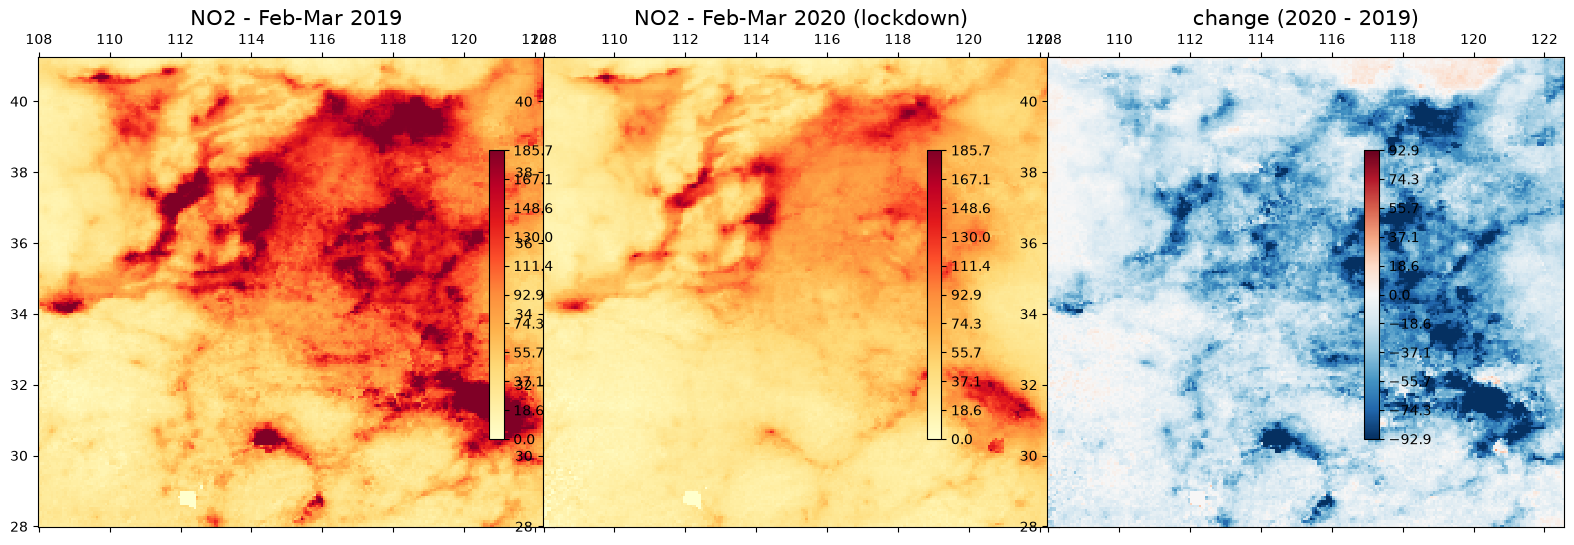

mean tropospheric NO2 fell 36% (Feb-Mar 2020 vs 2019)


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
plot_arr(
    n19, a2019, ax[0], cmap="YlOrRd", title="NO2 - Feb-Mar 2019", vmin=0, vmax=vmax
)
plot_arr(
    n20,
    a2020,
    ax[1],
    cmap="YlOrRd",
    title="NO2 - Feb-Mar 2020 (lockdown)",
    vmin=0,
    vmax=vmax,
)
plot_arr(
    n20 - n19,
    a2019,
    ax[2],
    cmap="RdBu_r",
    title="change (2020 - 2019)",
    vmin=-vmax / 2,
    vmax=vmax / 2,
)
plt.tight_layout()
plt.show()
print(
    f"mean tropospheric NO2 fell {(1 - np.nanmean(n20) / np.nanmean(n19)) * 100:.0f}% (Feb-Mar 2020 vs 2019)"
)

## 2 · Monthly time series, 2019–2021

To see the seasonal cycle, the lockdown dip, and the rebound, we fetch one mean
composite per month across three years and take the regional mean of each.

### Fetch one composite per month

Loop over every month of 2019–2021, building the same GEE request with a
one-month window each time. Each iteration constructs → `authenticate` → `load`,
then records the regional-mean NO₂ (in µmol/m²).

In [9]:
months, vals = [], []
for y in (2019, 2020, 2021):
    for m in range(1, 13):
        s = date(y, m, 1)
        e = date(y + (m == 12), (m % 12) + 1, 1)
        scene = EarthLens(
            data_source="gee",
            cadence="raw",
            dataset=DATASET,
            variables=[NO2],
            aoi=AOI,
            start=s.isoformat(),
            end=e.isoformat(),
            scale=7000,
            reducer="mean",
        )
        scene.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
        rasters = scene.load()
        p = rasters[0]
        if p:
            arr = np.asarray(p.read_array(), dtype="float32")
            arr = arr if arr.ndim == 2 else arr[0]
            months.append(pd.Timestamp(s))
            vals.append(np.nanmean(arr) * 1e6)
print(f"{len(vals)} monthly composites")

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]:   0%|          | 0/1 [00:00<?, ?img/s]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:04<00:00,  4.40s/img]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:04<00:00,  4.40s/img]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]:   0%|          | 0/1 [00:00<?, ?img/s]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:03<00:00,  3.66s/img]

...

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:06<00:00,  6.88s/img]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]:   0%|          | 0/1 [00:00<?, ?img/s]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:05<00:00,  5.67s/img]

COPERNICUS/S5P/OFFL/L3_NO2 [tropospheric_NO2_column_number_density]: 100%|██████████| 1/1 [00:05<00:00,  5.67s/img]

36 monthly composites


### Plot the series with the lockdown window shaded

Draw the monthly means as a line and shade the main China lockdown window
(Feb–Apr 2020) so the dip stands out against the seasonal cycle.

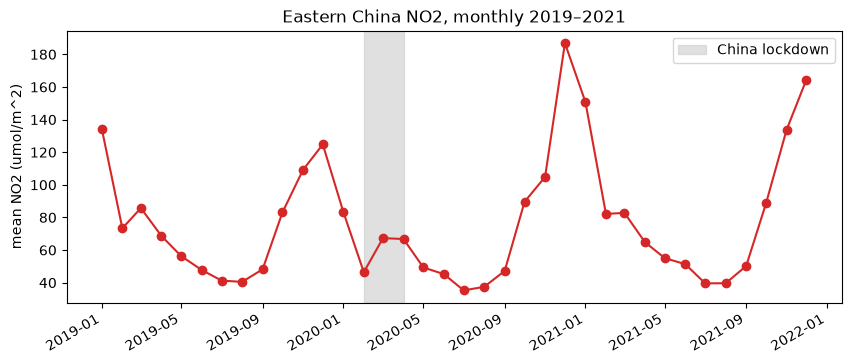

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(months, vals, "-o", color="tab:red")
ax.axvspan(
    pd.Timestamp("2020-02-01"),
    pd.Timestamp("2020-04-01"),
    color="0.8",
    alpha=0.6,
    label="China lockdown",
)
ax.set(ylabel="mean NO2 (umol/m^2)", title="Eastern China NO2, monthly 2019–2021")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Recap

The NO₂ maps (including the derived difference) are rendered with
`Dataset.plot()`; the monthly time series is a matplotlib chart.

### Try it yourself

- Re-point `AOI`, or compare other year pairs.
- See the [GEE backend reference](../../reference/gee/introduction.md).